<a href="https://colab.research.google.com/github/asomanibernard191-arch/Syntecxhub_Customer_Segmentation/blob/main/Syntecxhub_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Setting aesthetic style for plots
sns.set_theme(style="whitegrid")

# Loading the Mall Customers dataset directly from Kaggle's Public repository
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
df = pd.read_csv(url)

# Displaying basic information and first 5 rows
print(df.info())
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


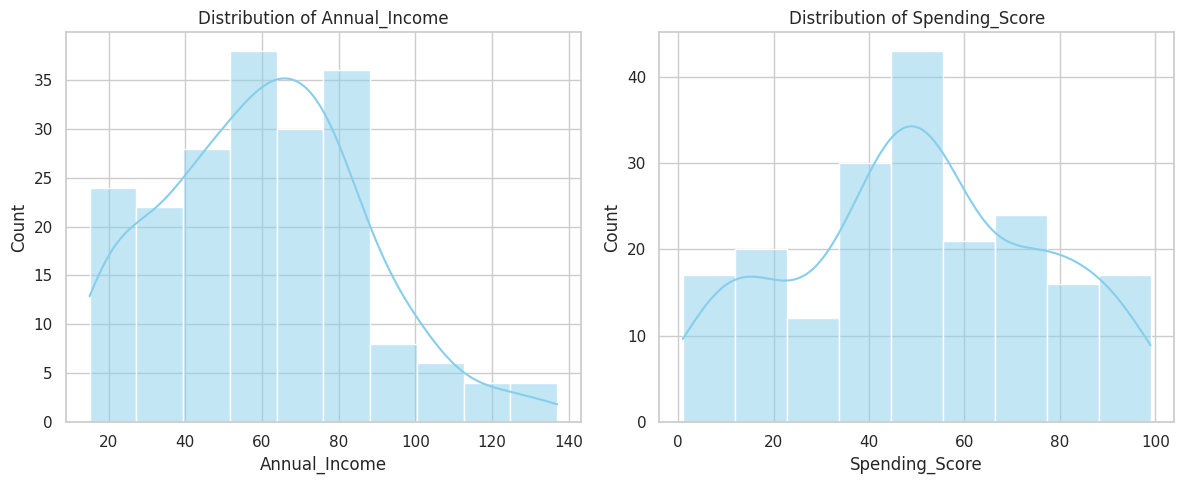

In [13]:
# Renaming columns for easier access
df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

# Selecting features for clustering
X = df[['Annual_Income', 'Spending_Score']].values

# Visualizing feature distributions using a loop
plt.figure(figsize=(12, 5))
features = ['Annual_Income', 'Spending_Score']

for i, feature in enumerate(features):
  plt.subplot(1, 2, i + 1)
  sns.histplot(df[feature], kde=True, color='skyblue')
  plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

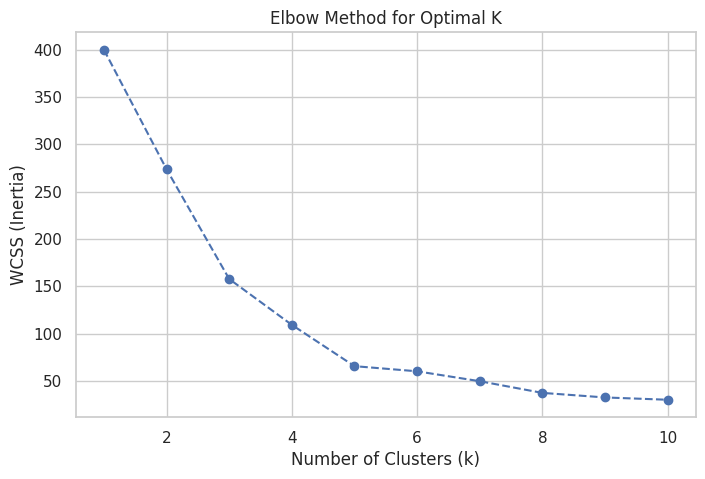

In [14]:
# Standardizing features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculating Within-Cluster Sum of Squares (WCSS) FOR k=1 to k=10
wcss = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

# Plotting the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.show()





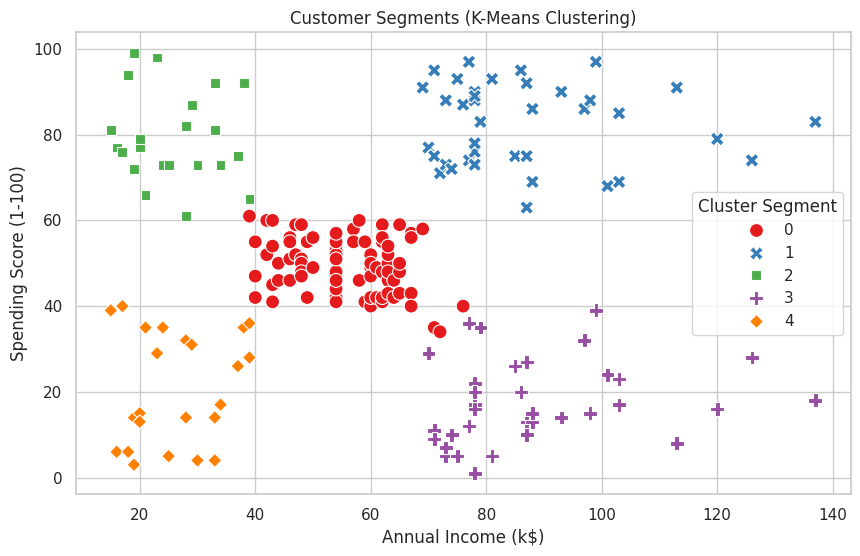

In [15]:
# Training K-Means with K=5
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
# Visualizing the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df['Annual_Income'],
    y=df['Spending_Score'],
    hue=df['Cluster'],
    palette='Set1',
    s=100,
    style=df['Cluster']
)

plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster Segment')
plt.show()

In [16]:
# Saving the updated DataFrame with cluster labels to a CSV file
df.to_csv('segmented_customers.csv', index=False)

